In [1]:
from iminuit import cost, Minuit
import numpy as np
from iminuit.cost import LeastSquares
import iminuit
from matplotlib import pyplot as plt
iminuit.__version__

'2.18.0'

<ErrorbarContainer object of 3 artists>

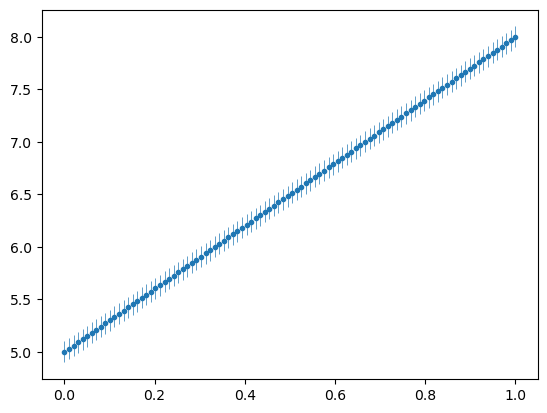

In [2]:
x = np.linspace(0, 1, 100)
y = 3*x+5
y_err = np.ones_like(y)*0.1
plt.errorbar(x, y, yerr=y_err, fmt='.', lw=0.5)

In [20]:
def line(x, a, b):
    return a*x+b
ls = iminuit.cost.LeastSquares(x, y, y_err, line)
m = Minuit(ls, a=0, b=0)
m.migrad()
m.hesse()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.34e-20 (chi2/ndof = 0.0) │              Nfcn = 46               │
│ EDM = 2.34e-20 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴───────────┴─────────────┴────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   3.000   │   0.034   │            │            │         │         │       │
│ 1 │ b    │   5.00    │   0.02    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬─────────────────────┐
│   │         a         b │
├───┼─────────────────────┤
│ a │   0.00118 -0.000588 │
│ b │ -0.000588  0.000394 │
└───┴─────────────────────┘

In [61]:
m.errors

<ErrorView a=0.034296320848562024 b=0.0198509295997256>

In [62]:
m.covariance

,a,b
a,0.00118,-0.000588 (-0.864)
b,-0.000588 (-0.864),0.000394


(<Figure size 640x480 with 4 Axes>,
 array([[<Axes: >, <Axes: >],
        [<Axes: xlabel='a', ylabel='b'>, <Axes: xlabel='b'>]], dtype=object))

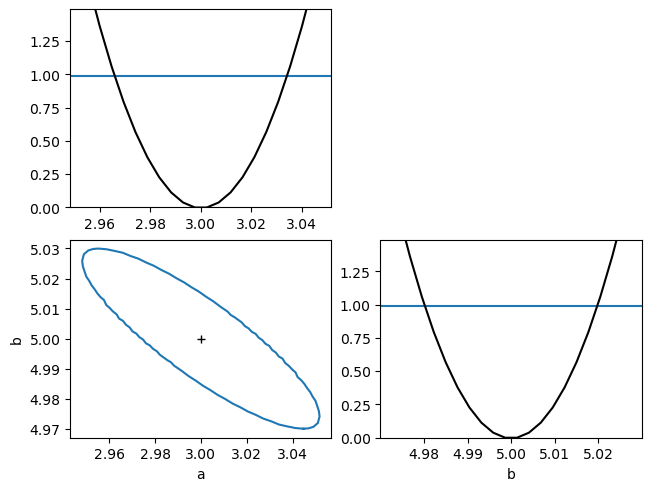

In [64]:
m.draw_mnmatrix()

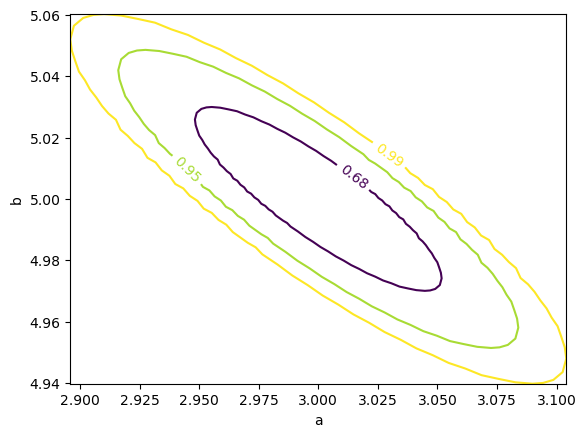

In [65]:
m.draw_mncontour('a', 'b', cl=(0.68, 0.95, 0.99))